In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, cross_val_score
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
import optuna

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'c:\Users\Egor\Desktop\VUZ\ML\MathE_dataset_processed.csv')

In [4]:
df.head()

,Student ID,Student Country,Question ID,Type of Answer,Topic,Subtopic,Keywords,level_Advanced,level_Basic,"subtopic_Algebraic expressions, Equations, and Inequalities",...,Triangles,Trigonometric form,Trigonometric rules,Trigonometric substitution,Unconstrained optimization,Undetermined solution of linear system,Variance,and total probability rules,multiplication,y-simple region (type I)
0,647,Ireland,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,41,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,340,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,641,Italy,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,669,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
target_col = 'Type of Answer'

# Отбросим нечисловые (строковые) и идентификационные столбцы, оставим только числовые признаки для обучения
features = df.select_dtypes(include=[np.number]).drop(columns=[target_col, 'Student ID', 'Question ID'], errors='ignore')
X = features
y = df[target_col]

2) Разбиение на обучающую и тестовую выборки со стратификацией

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (5970, 187)
Размер тестовой выборки: (1493, 187)


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
unique_classes = y.nunique()

In [ ]:
unique_classes

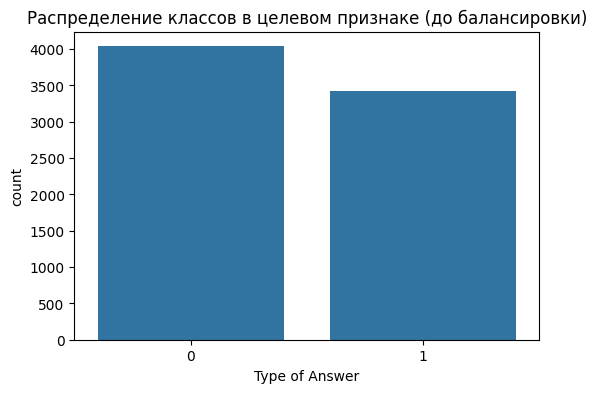

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Распределение классов в целевом признаке (до балансировки)')
plt.show()

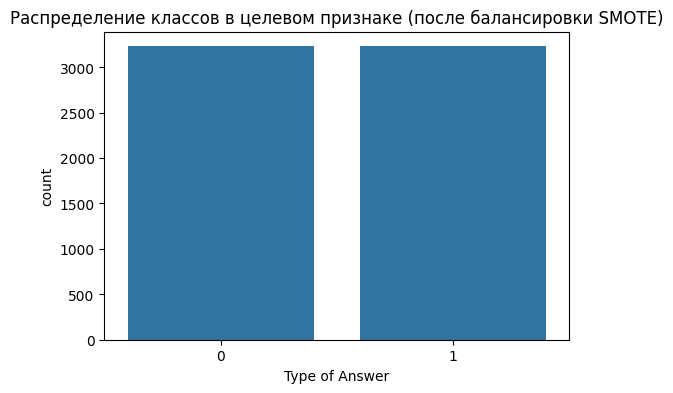

In [9]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_balanced)
plt.title('Распределение классов в целевом признаке (после балансировки SMOTE)')
plt.show()

4. Решение задачи классификации и подбор гиперпараметров

In [10]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2']}
grid_lr = GridSearchCV(logreg, param_grid_lr, cv=kf, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_balanced, y_train_balanced)
print("Лучшие параметры (LR GridSearch):", grid_lr.best_params_)


Лучшие параметры (LR GridSearch): {'C': 0.01, 'penalty': 'l2'}


In [17]:
print(f"Лучшая метрика accuracy (LR GridSearch): {grid_lr.best_score_:.4f}")

Лучшая метрика accuracy (LR GridSearch): 0.5460


In [12]:
param_dist_lr = {'C': np.logspace(-3, 3, 20), 'penalty': ['l2']}
rand_lr = RandomizedSearchCV(logreg, param_dist_lr, cv=kf, scoring='accuracy', n_iter=10, random_state=42, n_jobs=-1)
rand_lr.fit(X_train_balanced, y_train_balanced)
print("Лучшие параметры (LR RandomSearch):", rand_lr.best_params_)

Лучшие параметры (LR RandomSearch): {'penalty': 'l2', 'C': np.float64(0.008858667904100823)}


In [18]:
print(f"Лучшая метрика accuracy (LR RandomSearch): {rand_lr.best_score_:.4f}")

Лучшая метрика accuracy (LR RandomSearch): 0.5457


In [13]:
best_lr = grid_lr.best_estimator_

In [14]:
knn = KNeighborsClassifier()

In [15]:
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(knn, param_grid_knn, cv=kf, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_balanced, y_train_balanced)
print("Лучшие параметры (KNN GridSearch):", grid_knn.best_params_)

Лучшие параметры (KNN GridSearch): {'n_neighbors': 11, 'weights': 'uniform'}


In [19]:
print(f"Лучшая метрика accuracy (KNN GridSearch): {grid_knn.best_score_:.4f}")

Лучшая метрика accuracy (KNN GridSearch): 0.5221


In [16]:
param_dist_knn = {'n_neighbors': range(1, 20), 'weights': ['uniform', 'distance'], 'p': [1, 2]}
rand_knn = RandomizedSearchCV(knn, param_dist_knn, cv=kf, scoring='accuracy', n_iter=10, random_state=42, n_jobs=-1)
rand_knn.fit(X_train_balanced, y_train_balanced)
print("Лучшие параметры (KNN RandomSearch):", rand_knn.best_params_)

best_knn = grid_knn.best_estimator_

Лучшие параметры (KNN RandomSearch): {'weights': 'uniform', 'p': 1, 'n_neighbors': 1}


In [20]:
print(f"Лучшая метрика accuracy (KNN RandomSearch): {rand_knn.best_score_:.4f}")

Лучшая метрика accuracy (KNN RandomSearch): 0.5232


In [21]:
def objective_nb(trial):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-10, 1e-2, log=True)
    nb = GaussianNB(var_smoothing=var_smoothing)
    score = cross_val_score(nb, X_train_balanced, y_train_balanced, cv=kf, scoring='accuracy').mean()
    return score

In [22]:
study_nb = optuna.create_study(direction='maximize')
study_nb.optimize(objective_nb, n_trials=20)
print("Лучшие параметры (NB Optuna):", study_nb.best_params)
print(f"Лучшая метрика accuracy (NB Optuna): {study_nb.best_value:.4f}")

best_nb = GaussianNB(**study_nb.best_params)
best_nb.fit(X_train_balanced, y_train_balanced)

[I 2026-05-28 08:46:44,827] A new study created in memory with name: no-name-ef54af3d-2591-4ffe-9b42-d036adda8700
[I 2026-05-28 08:46:44,945] Trial 0 finished with value: 0.5308188626667595 and parameters: {'var_smoothing': 0.0060102726656993824}. Best is trial 0 with value: 0.5308188626667595.
[I 2026-05-28 08:46:45,043] Trial 1 finished with value: 0.5305092651435397 and parameters: {'var_smoothing': 1.564052760380224e-08}. Best is trial 0 with value: 0.5308188626667595.
[I 2026-05-28 08:46:45,139] Trial 2 finished with value: 0.5305092651435397 and parameters: {'var_smoothing': 4.993098069391189e-06}. Best is trial 0 with value: 0.5308188626667595.
[I 2026-05-28 08:46:45,220] Trial 3 finished with value: 0.5305092651435397 and parameters: {'var_smoothing': 3.1136310069655783e-07}. Best is trial 0 with value: 0.5308188626667595.
[I 2026-05-28 08:46:45,306] Trial 4 finished with value: 0.5305092651435397 and parameters: {'var_smoothing': 2.266713247420122e-08}. Best is trial 0 with va

Лучшие параметры (NB Optuna): {'var_smoothing': 0.0060102726656993824}
Лучшая метрика accuracy (NB Optuna): 0.5308


,priors,None
,var_smoothing,0.0060102726656993824


In [23]:
def exponential_kernel(X, Y, gamma=0.1):
    dists = pairwise_distances(X, Y, metric='euclidean')
    return np.exp(-gamma * dists)

In [24]:
def objective_svm(trial):
    # Тестируем стандартные ядра: 'linear', 'poly', 'rbf', 'sigmoid'
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])
    C = trial.suggest_float('C', 0.1, 10, log=True)
    
    svm = SVC(kernel=kernel, C=C, probability=True, random_state=42)
    # Для ускорения можно использовать подвыборку, но мы делаем полноценную CV
    score = cross_val_score(svm, X_train_balanced, y_train_balanced, cv=kf, scoring='accuracy', n_jobs=-1).mean()
    return score

In [25]:
study_svm = optuna.create_study(direction='maximize')
# Ограничим число испытаний до 10 для экономии времени обучения (можно увеличить)
study_svm.optimize(objective_svm, n_trials=10)
print("Лучшие параметры (SVM Optuna):", study_svm.best_params)
print(f"Лучшая метрика accuracy (SVM Optuna): {study_svm.best_value:.4f}")

[I 2026-05-28 08:48:32,271] A new study created in memory with name: no-name-848a3060-9af7-4752-92b5-5df12c70ecdd
[I 2026-05-28 08:51:23,034] Trial 0 finished with value: 0.5421206111373572 and parameters: {'kernel': 'linear', 'C': 6.244009111837334}. Best is trial 0 with value: 0.5421206111373572.
[I 2026-05-28 08:52:23,190] Trial 1 finished with value: 0.541501056372649 and parameters: {'kernel': 'linear', 'C': 0.12395217079700555}. Best is trial 0 with value: 0.5421206111373572.
[I 2026-05-28 08:53:32,811] Trial 2 finished with value: 0.533758600264273 and parameters: {'kernel': 'sigmoid', 'C': 0.2071449527776153}. Best is trial 0 with value: 0.5421206111373572.
[I 2026-05-28 08:54:37,903] Trial 3 finished with value: 0.5415011762787386 and parameters: {'kernel': 'rbf', 'C': 0.3778266578113813}. Best is trial 0 with value: 0.5421206111373572.
[I 2026-05-28 08:55:42,077] Trial 4 finished with value: 0.5357694253860377 and parameters: {'kernel': 'sigmoid', 'C': 4.167762829537163}. Bes

Лучшие параметры (SVM Optuna): {'kernel': 'rbf', 'C': 2.256284678582285}
Лучшая метрика accuracy (SVM Optuna): 0.5429


In [26]:
best_svm = SVC(**study_svm.best_params, probability=True, random_state=42)
best_svm.fit(X_train_balanced, y_train_balanced)

,C,2.256284678582285
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [27]:
best_svm_exp = SVC(kernel=exponential_kernel, C=1.0, probability=True, random_state=42)
best_svm_exp.fit(X_train_balanced, y_train_balanced)

,C,1.0
,kernel,<function exp...0019CA2145630>
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# ## 5. Оценка качества моделей


--- Оценка модели: Logistic Regression ---
              precision    recall  f1-score   support

           0       0.59      0.59      0.59       808
           1       0.52      0.52      0.52       685

    accuracy                           0.56      1493
   macro avg       0.55      0.55      0.55      1493
weighted avg       0.56      0.56      0.56      1493



<Figure size 1000x800 with 0 Axes>

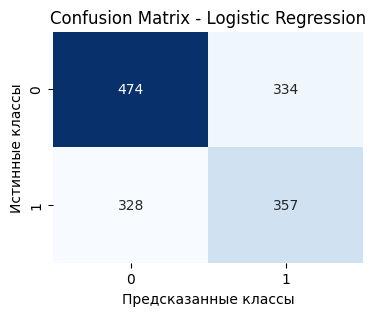


--- Оценка модели: KNN ---
              precision    recall  f1-score   support

           0       0.56      0.71      0.63       808
           1       0.50      0.34      0.41       685

    accuracy                           0.54      1493
   macro avg       0.53      0.53      0.52      1493
weighted avg       0.53      0.54      0.53      1493



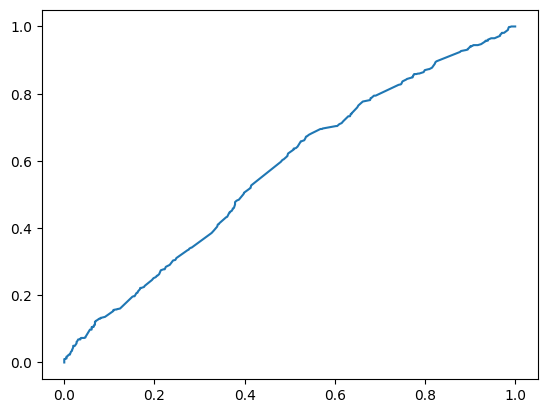

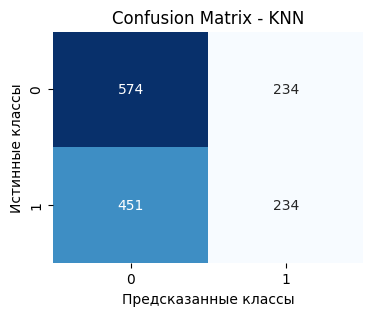


--- Оценка модели: Naive Bayes ---
              precision    recall  f1-score   support

           0       0.56      0.73      0.63       808
           1       0.50      0.31      0.38       685

    accuracy                           0.54      1493
   macro avg       0.53      0.52      0.51      1493
weighted avg       0.53      0.54      0.52      1493



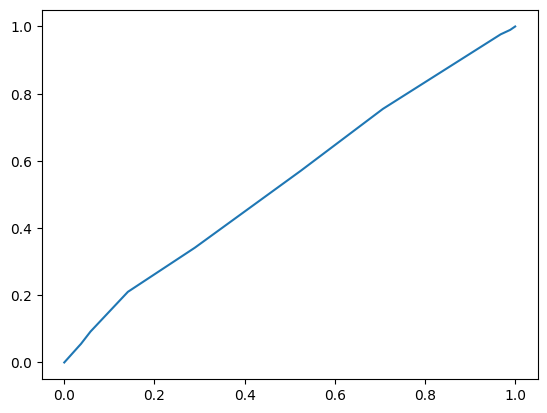

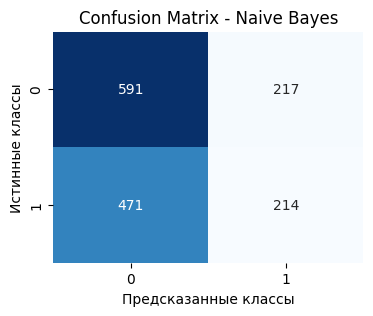


--- Оценка модели: SVM (Best from Optuna) ---
              precision    recall  f1-score   support

           0       0.60      0.51      0.55       808
           1       0.51      0.60      0.55       685

    accuracy                           0.55      1493
   macro avg       0.56      0.56      0.55      1493
weighted avg       0.56      0.55      0.55      1493



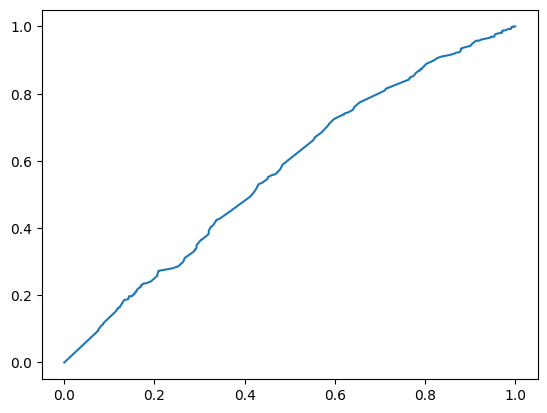

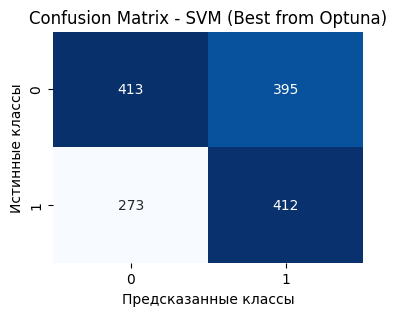


--- Оценка модели: SVM (Exponential Kernel) ---
              precision    recall  f1-score   support

           0       0.60      0.55      0.57       808
           1       0.51      0.56      0.54       685

    accuracy                           0.55      1493
   macro avg       0.55      0.55      0.55      1493
weighted avg       0.56      0.55      0.55      1493



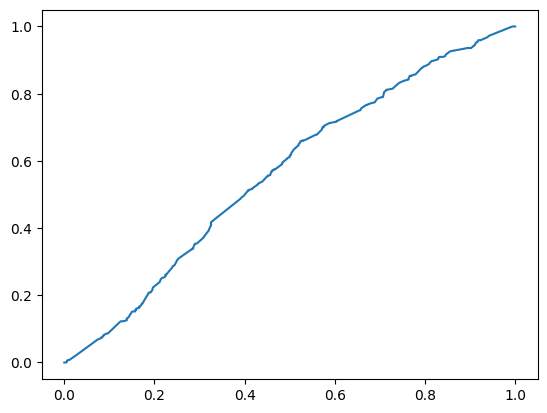

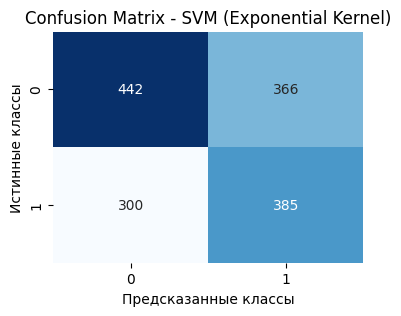

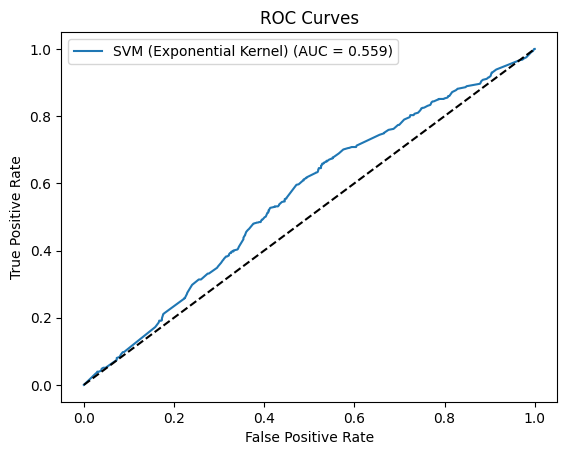

In [28]:
models = {
    'Logistic Regression': best_lr,
    'KNN': best_knn,
    'Naive Bayes': best_nb,
    'SVM (Best from Optuna)': best_svm,
    'SVM (Exponential Kernel)': best_svm_exp
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"--- Оценка модели: {name} ---")
    y_pred = model.predict(X_test_scaled)
    # predict_proba поддерживается не всеми конфигурациями, делаем проверку
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1] 
    else:
        y_proba = None
    
    print(classification_report(y_test, y_pred))
    
    # Матрица путаницы
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Истинные классы')
    plt.xlabel('Предсказанные классы')
    plt.show()
    
    # Сбор данных для ROC-AUC кривой
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.figure(1) # Переключаемся на общий график ROC
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

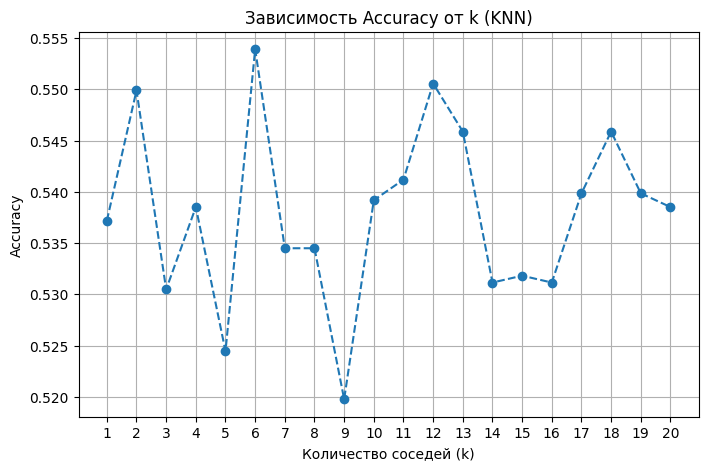

In [29]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_balanced, y_train_balanced)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_temp))

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed')
plt.title('Зависимость Accuracy от k (KNN)')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid()
plt.show()

In [30]:
def numpy_metrics(y_true, y_pred, y_prob=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    conf_matrix = np.array([[TN, FP], [FN, TP]])
    
    auc_score = None
    if y_prob is not None:
        # Вычисление ROC-AUC через трапеции
        desc_score_indices = np.argsort(y_prob)[::-1]
        y_true_sorted = y_true[desc_score_indices]
        
        tpr_list = []
        fpr_list = []
        
        pos_count = np.sum(y_true == 1)
        neg_count = np.sum(y_true == 0)
        
        tp = 0
        fp = 0
        
        for yt in y_true_sorted:
            if yt == 1:
                tp += 1
            else:
                fp += 1
            tpr_list.append(tp / pos_count)
            fpr_list.append(fp / neg_count)
            
        auc_score = np.trapz(tpr_list, fpr_list)
        
    return accuracy, precision, recall, f1, conf_matrix, auc_score

y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

acc, prec, rec, f1, cm, auc = numpy_metrics(y_test, y_pred_lr, y_prob_lr)

print("--- Сравнение метрик (На примере Логистической регрессии) ---")
print(f"NumPy Accuracy: {acc:.4f} | Sklearn: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"NumPy F1-Score: {f1:.4f} | Sklearn: {classification_report(y_test, y_pred_lr, output_dict=True)['1']['f1-score']:.4f}")
print("NumPy Confusion Matrix:\n", cm)
print("Sklearn Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print(f"NumPy ROC-AUC: {auc:.4f} | Sklearn: {roc_auc_score(y_test, y_prob_lr):.4f}")

--- Сравнение метрик (На примере Логистической регрессии) ---
NumPy Accuracy: 0.5566 | Sklearn: 0.5566
NumPy F1-Score: 0.5189 | Sklearn: 0.5189
NumPy Confusion Matrix:
 [[474 334]
 [328 357]]
Sklearn Confusion Matrix:
 [[474 334]
 [328 357]]
NumPy ROC-AUC: 0.5719 | Sklearn: 0.5717


In [32]:
class CustomKNN:
    def __init__(self, k=3, metric='euclidean'):
        self.k = k
        self.metric = metric
        
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        
    def predict(self, X):
        X = np.array(X)
        predictions = []
        # Векторизованное вычисление расстояний для ускорения
        for x in X:
            if self.metric == 'euclidean':
                distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            elif self.metric == 'manhattan':
                distances = np.sum(np.abs(self.X_train - x), axis=1)
            elif self.metric == 'chebyshev':
                distances = np.max(np.abs(self.X_train - x), axis=1)
            else:
                raise ValueError("Unknown metric")
                
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = self.y_train[k_indices]
            
            # Majority vote
            unique, counts = np.unique(k_nearest_labels, return_counts=True)
            pred = unique[np.argmax(counts)]
            predictions.append(pred)
        return np.array(predictions)

# Тестируем кастомный KNN на всей выборке
custom_knn = CustomKNN(k=5, metric='manhattan')

custom_knn.fit(X_train_balanced, y_train_balanced)
y_pred_custom = custom_knn.predict(X_test_scaled) 

print(f"\nМетрики Custom KNN (Manhattan, k=5) на всей тестовой выборке:")
acc_cust, prec_cust, rec_cust, f1_cust, cm_cust, _ = numpy_metrics(y_test, y_pred_custom)
print(f"Accuracy: {acc_cust:.4f}")
print(f"Precision: {prec_cust:.4f}")
print(f"Recall: {rec_cust:.4f}")
print(f"F1-score: {f1_cust:.4f}")


Метрики Custom KNN (Manhattan, k=5) на всей тестовой выборке:
Accuracy: 0.5325
Precision: 0.4926
Recall: 0.6307
F1-score: 0.5531
